# CMPINAM — Aula 06
## Regressão Logística na prática: Titanic

Neste notebook, vamos **aplicar diretamente** os conceitos discutidos nos slides.

### Objetivos
- preparar os dados do Titanic;
- treinar uma Regressão Logística;
- comparar `predict()` e `predict_proba()`;
- avaliar o modelo com **acurácia, precisão, recall, F1-score e matriz de confusão**;
- comparar o modelo com um **baseline simples**;
- observar o efeito da mudança do **limiar de decisão**;
- inspecionar, de forma introdutória, os **coeficientes aprendidos** pelo modelo.


## 1. Imports

Se necessário, instale antes:

```bash
pip install pandas seaborn matplotlib scikit-learn
```


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)


## 2. Carregando o Titanic

Vamos trabalhar diretamente com o problema:

> **A partir das características de um passageiro, o modelo consegue estimar se ele sobreviveu?**

A variável-alvo será `survived`:

- `0` → não sobreviveu
- `1` → sobreviveu


In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [28]:
# Selecionar as crianças que sobreviveram e as que não sobreviveram
df_children = df[df["age"] < 16]

df_children['who'].value_counts()

who
child    83
Name: count, dtype: int64

## 3. Uma inspeção rápida dos dados

Não faremos uma análise exploratória extensa. Queremos apenas entender o tamanho da base, a proporção das classes e os valores ausentes.


In [3]:
print("Dimensões:", df.shape)

print("\nDistribuição da classe:")
display(
    df["survived"]
      .value_counts()
      .rename(index={0: "Não sobreviveu", 1: "Sobreviveu"})
      .to_frame("quantidade")
)

print("\nProporção da classe:")
display(
    df["survived"]
      .value_counts(normalize=True)
      .rename(index={0: "Não sobreviveu", 1: "Sobreviveu"})
      .mul(100)
      .round(1)
      .to_frame("percentual (%)")
)

features = ["age", "sibsp", "parch", "fare", "pclass", "sex", "embarked"]

print("\nValores ausentes nas variáveis que usaremos:")
display(df[features].isna().sum().to_frame("ausentes"))


Dimensões: (891, 15)

Distribuição da classe:


,quantidade
survived,
Não sobreviveu,549
Sobreviveu,342



Proporção da classe:


,percentual (%)
survived,
Não sobreviveu,61.6
Sobreviveu,38.4



Valores ausentes nas variáveis que usaremos:


,ausentes
age,177
sibsp,0
parch,0
fare,0
pclass,0
sex,0
embarked,2


### Uma única visualização

Antes de treinar o modelo, observe uma relação simples entre uma característica e a sobrevivência.

**Pergunta:** a proporção de sobreviventes parece igual entre homens e mulheres?


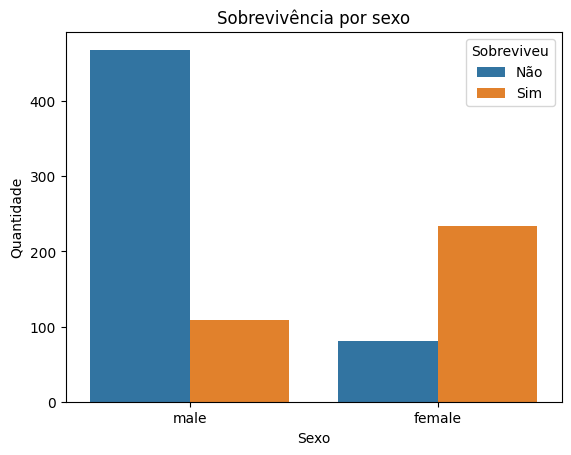

In [4]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Sobrevivência por sexo")
plt.xlabel("Sexo")
plt.ylabel("Quantidade")
plt.legend(title="Sobreviveu", labels=["Não", "Sim"])
plt.show()

## 4. Variáveis do modelo

Usaremos um conjunto pequeno de características para manter a prática legível.

### Numéricas
- `age`
- `sibsp`
- `parch`
- `fare`
- `pclass`

### Categóricas
- `sex`
- `embarked`

Antes de executar a próxima célula, pense:

> **Quais dessas características você espera que tenham maior relação com a sobrevivência?**


In [5]:
num_features = ["age", "sibsp", "parch", "fare", "pclass"]
cat_features = ["sex", "embarked"]

X = df[num_features + cat_features]
y = df["survived"]

X.head()

,age,sibsp,parch,fare,pclass,sex,embarked
0,22.0,1,0,7.2500,3,male,S
1,38.0,1,0,71.2833,1,female,C
2,26.0,0,0,7.9250,3,female,S
3,35.0,1,0,53.1000,1,female,S
4,35.0,0,0,8.0500,3,male,S


In [7]:
X['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

## 5. Separando treino e teste

Usamos `stratify=y` para preservar aproximadamente a proporção das classes nos dois conjuntos.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

print("\nProporção de sobreviventes:")
print("Treino:", round(y_train.mean(), 3))
print("Teste :", round(y_test.mean(), 3))


Treino: (668, 7)
Teste : (223, 7)

Proporção de sobreviventes:
Treino: 0.383
Teste : 0.386


## 6. Pré-processamento + Regressão Logística

Vamos colocar todo o fluxo em um `Pipeline`.

- valores numéricos ausentes → mediana;
- variáveis numéricas → padronização;
- valores categóricos ausentes → categoria mais frequente;
- variáveis categóricas → One-Hot Encoding;
- modelo → `LogisticRegression`.


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(C=1.0, max_iter=1000))
])

model


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 7. Treinando o modelo

Aqui ocorre o ajuste dos parâmetros da Regressão Logística a partir dos dados de treino.


In [10]:
model.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


## 8. O que realmente entra no modelo?

Até aqui trabalhamos com a tabela original, que ainda contém:

- valores ausentes (`NaN`);
- categorias em texto, como `male`, `female`, `S`, `C` e `Q`;
- variáveis numéricas em escalas muito diferentes.

O `Pipeline` transforma esses dados **antes de entregá-los à Regressão Logística**.

Vamos comparar o antes e o depois.


In [11]:
# Algumas linhas antes das transformações
X_test.head()

,age,sibsp,parch,fare,pclass,sex,embarked
157,30.0,0,0,8.0500,3,male,S
501,21.0,0,0,7.7500,3,female,Q
352,15.0,1,1,7.2292,3,male,C
82,NaN,0,0,7.7875,3,female,Q
683,14.0,5,2,46.9000,3,male,S


In [12]:
# Aplicando somente o pré-processamento já aprendido no treino
X_test_transformado = (
    model.named_steps["preprocessor"]
         .transform(X_test)
)

# Recuperando os nomes das colunas após as transformações
nomes_colunas = (
    model.named_steps["preprocessor"]
         .get_feature_names_out()
)

df_transformado = pd.DataFrame(
    X_test_transformado,
    columns=nomes_colunas,
    index=X_test.index
)

df_transformado.head().round(3)


,num__age,num__sibsp,num__parch,num__fare,num__pclass,cat__sex_male,cat__embarked_Q,cat__embarked_S
157,0.019,-0.465,-0.451,-0.488,0.827,1.0,0.0,1.0
501,-0.675,-0.465,-0.451,-0.494,0.827,0.0,1.0,0.0
352,-1.139,0.537,0.750,-0.505,0.827,1.0,0.0,0.0
82,-0.058,-0.465,-0.451,-0.493,0.827,0.0,1.0,0.0
683,-1.216,4.542,1.952,0.332,0.827,1.0,0.0,1.0


### O que mudou?

Observe a tabela transformada:

- `age`, `fare`, `pclass` e demais variáveis numéricas foram **preenchidas quando necessário e padronizadas**;
- `sex` deixou de ser texto e passou a ser representado por uma coluna como `cat__sex_male`;
- `embarked` foi convertido em colunas numéricas pelo One-Hot Encoding;
- o modelo recebe **somente números**.

> A tabela original não é alterada. As transformações acontecem dentro do `Pipeline`.


### Um passageiro antes e depois

Vamos observar um caso específico em que `age` está ausente na tabela original.

O objetivo é perceber que o `NaN` continua existindo em `X_test`, mas o valor entregue ao modelo já foi tratado pelo pipeline.


In [13]:
# Procurando automaticamente um passageiro do conjunto de teste com idade ausente
indices_age_ausente = X_test.index[X_test["age"].isna()]

if len(indices_age_ausente) > 0:
    indice = indices_age_ausente[0]

    print(f"Passageiro selecionado: índice {indice}")

    print("\nANTES DAS TRANSFORMAÇÕES:")
    display(X_test.loc[[indice]])

    print("\nDEPOIS DAS TRANSFORMAÇÕES:")
    display(df_transformado.loc[[indice]].round(3))
else:
    print("Não há passageiros com age ausente neste conjunto de teste.")


Passageiro selecionado: índice 82

ANTES DAS TRANSFORMAÇÕES:


,age,sibsp,parch,fare,pclass,sex,embarked
82,NaN,0,0,7.7875,3,female,Q



DEPOIS DAS TRANSFORMAÇÕES:


,num__age,num__sibsp,num__parch,num__fare,num__pclass,cat__sex_male,cat__embarked_Q,cat__embarked_S
82,-0.058,-0.465,-0.451,-0.493,0.827,0.0,1.0,0.0


### Para interpretar

No exemplo acima, observe especialmente:

1. `age` aparece como `NaN` antes da transformação?
2. Depois do pipeline, ainda existe `NaN` nessa posição?
3. O que aconteceu com `sex` e `embarked`?
4. Por que os valores de `age`, `fare` e `pclass` não aparecem mais na escala original?

**Ideia central:** o modelo não recebe diretamente a tabela original; ele recebe a versão numérica produzida pelo pré-processamento.


## 9. Classe prevista × probabilidade

Agora vamos observar as duas saídas discutidas nos slides:

- `predict_proba()` → probabilidades;
- `predict()` → classe final.


In [14]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

resultado = X_test.copy()
resultado["real"] = y_test.values
resultado["prob_sobreviver"] = y_proba
resultado["classe_prevista"] = y_pred

resultado[["real", "prob_sobreviver", "classe_prevista"]].head(10).round(3)

,real,prob_sobreviver,classe_prevista
157,0,0.086,0
501,0,0.765,1
352,0,0.156,0
82,1,0.702,1
683,0,0.051,0
84,1,0.860,1
779,1,0.917,1
515,0,0.317,0
728,0,0.222,0
734,0,0.277,0


### Para interpretar

Observe algumas linhas da tabela anterior.

1. Uma probabilidade maior que `0,5` normalmente resulta em qual classe?
2. Encontre um caso em que a probabilidade esteja próxima de `0,5`.
3. A probabilidade e a classe representam a mesma informação?


## 10. Métricas de classificação

Vamos calcular as quatro métricas trabalhadas na aula.


In [15]:
metricas = pd.Series({
    "Acurácia": accuracy_score(y_test, y_pred),
    "Precisão": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
})

display(metricas.round(3).to_frame("valor"))


,valor
Acurácia,0.771
Precisão,0.716
Recall,0.674
F1-score,0.695


### Não basta olhar o número

Responda com base nos resultados obtidos:

- O que a **acurácia** está dizendo?
- Quando o modelo prevê sobrevivência, o que a **precisão** nos informa?
- Entre os passageiros que realmente sobreviveram, o que o **recall** nos informa?
- Precisão e recall estão muito desequilibrados? O que o **F1-score** ajuda a resumir?


## 11. Matriz de confusão

Agora vamos enxergar **como** o modelo acertou e errou.


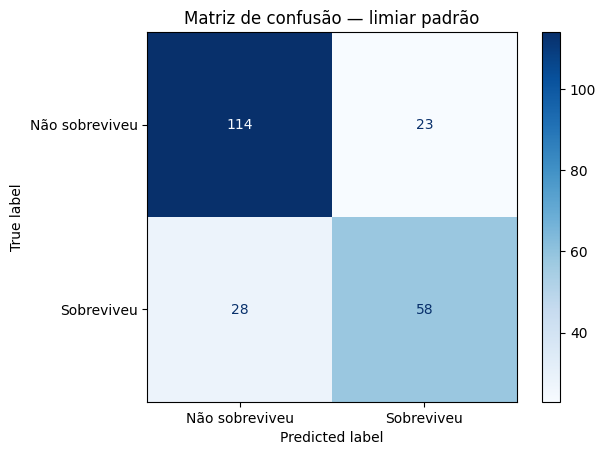

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Não sobreviveu", "Sobreviveu"],
    cmap="Blues"
)

plt.title("Matriz de confusão — limiar padrão")
plt.show()


### Leia a matriz

Identifique diretamente na matriz:

1. quantos passageiros que **sobreviveram** foram encontrados pelo modelo;
2. quantos sobreviventes o modelo **deixou passar**;
3. quantos passageiros foram previstos como sobreviventes, mas **não sobreviveram**;
4. quantos não sobreviventes foram classificados corretamente.

> O objetivo aqui não é apenas decorar VP, VN, FP e FN, mas interpretar o tipo de erro cometido.


## 12. Comparando com um baseline simples

Uma acurácia isolada não diz se o modelo realmente aprendeu algo útil.

Vamos comparar a Regressão Logística com uma estratégia extremamente simples:

> **prever sempre a classe mais frequente no conjunto de treino.**


In [17]:
classe_mais_frequente = y_train.mode()[0]
baseline_pred = np.full(len(y_test), classe_mais_frequente)

baseline_acc = accuracy_score(y_test, baseline_pred)
modelo_acc = accuracy_score(y_test, y_pred)

comparacao = pd.Series({
    "Baseline — sempre classe mais frequente": baseline_acc,
    "Regressão Logística": modelo_acc
})

display(comparacao.round(3).to_frame("acurácia"))


,acurácia
Baseline — sempre classe mais frequente,0.614
Regressão Logística,0.771


### Pergunta

A Regressão Logística superou a estratégia ingênua?

Explique por que a comparação com um **baseline** ajuda a interpretar a acurácia do modelo.


## 13. Mudando o limiar de decisão

O modelo produz probabilidades. A classe depende do ponto de corte escolhido.

Vamos testar três limiares:

- `0,30`
- `0,50`
- `0,70`

O modelo **não será treinado novamente**.


In [18]:
resultados_limiar = []

for threshold in [0.30, 0.50, 0.70]:
    pred_threshold = (y_proba >= threshold).astype(int)

    resultados_limiar.append({
        "Limiar": threshold,
        "Precisão": precision_score(y_test, pred_threshold),
        "Recall": recall_score(y_test, pred_threshold),
        "F1-score": f1_score(y_test, pred_threshold)
    })

df_limiares = pd.DataFrame(resultados_limiar)
df_limiares.round(3)


,Limiar,Precisão,Recall,F1-score
0,0.3,0.636,0.814,0.714
1,0.5,0.716,0.674,0.695
2,0.7,0.894,0.488,0.632


### O que mudou?

Compare as três linhas da tabela.

- Quando o limiar diminui, o modelo classifica **mais ou menos** passageiros como sobreviventes?
- O que aconteceu com a **precisão**?
- O que aconteceu com o **recall**?
- Qual limiar você escolheria se o mais importante fosse **não deixar sobreviventes de fora**?

> Não existe um limiar ideal para todos os problemas. A escolha depende do custo dos erros no domínio.


## 14. Comparando matrizes com limiares diferentes

Execute uma célula de cada vez e observe especialmente os **falsos positivos** e **falsos negativos**.


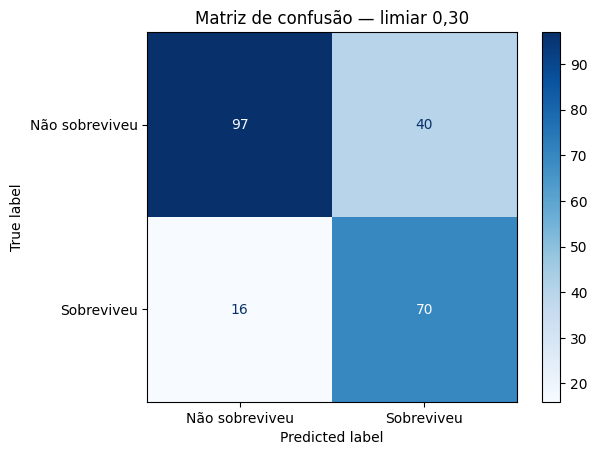

In [19]:
pred_030 = (y_proba >= 0.30).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_030,
    display_labels=["Não sobreviveu", "Sobreviveu"],
    cmap="Blues"
)
plt.title("Matriz de confusão — limiar 0,30")
plt.show()


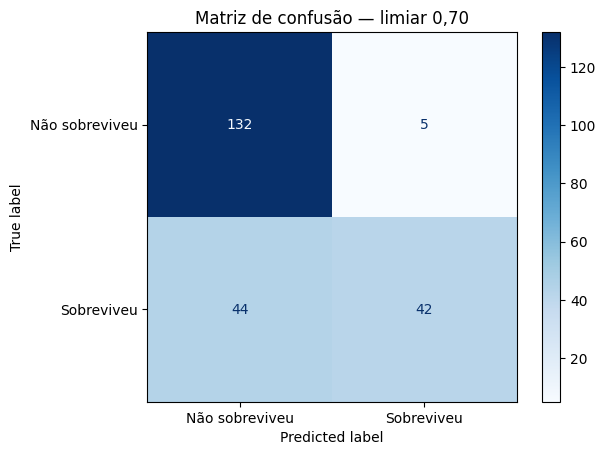

In [20]:
pred_070 = (y_proba >= 0.70).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_070,
    display_labels=["Não sobreviveu", "Sobreviveu"],
    cmap="Blues"
)
plt.title("Matriz de confusão — limiar 0,70")
plt.show()


## 15. Quais pesos o modelo aprendeu?

A Regressão Logística aprendeu coeficientes para as características após o pré-processamento.

Aqui não faremos uma análise estatística aprofundada. Queremos apenas conectar esta saída ao conceito discutido nos slides:

> **o treinamento ajusta pesos que influenciam o score e, consequentemente, a probabilidade prevista.**


In [21]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coeficientes = model.named_steps["classifier"].coef_[0]

df_coef = (
    pd.DataFrame({
        "caracteristica": feature_names,
        "coeficiente": coeficientes
    })
    .sort_values("coeficiente")
)

display(df_coef.round(3))

,caracteristica,coeficiente
5,cat__sex_male,-2.540
4,num__pclass,-0.920
0,num__age,-0.526
7,cat__embarked_S,-0.350
1,num__sibsp,-0.249
2,num__parch,-0.026
3,num__fare,0.133
6,cat__embarked_Q,0.290


### Leitura introdutória dos coeficientes

- coeficientes **positivos** empurram o score na direção da classe `1`;
- coeficientes **negativos** empurram o score na direção da classe `0`;
- o tamanho dos coeficientes deve ser interpretado com cuidado por causa do pré-processamento e da codificação das variáveis.

**Pergunta:** quais características aparecem com os coeficientes mais positivos e mais negativos neste ajuste?


## 16. Síntese da prática

Complete oralmente ou por escrito:

1. `predict_proba()` fornece __________________________.
2. `predict()` fornece ________________________________.
3. A matriz de confusão ajuda a identificar ________________________________.
4. Um baseline serve para _________________________________________________.
5. Ao aumentar o limiar, a precisão tende a __________ e o recall tende a __________.
6. O treinamento da Regressão Logística ajusta _____________________________.

### Ideia principal

> **Treinar o modelo é apenas parte do trabalho. Em classificação, também precisamos interpretar probabilidades, erros, métricas e o limiar usado para tomar a decisão.**
